# 03 — Credit Risk Mapping

**Purpose**: Visualise and verify the LTV structural transmission model before running the full Monte Carlo simulation.

**Input**: `data/processed/portfolio.csv` — from Notebook 02.

**Output**: Diagnostic figures in `outputs/figures/decision1/`. No data outputs — this is a verification notebook only.

**What this notebook does**:
1. Loads the portfolio and model parameters from config
2. Plots the full transmission chain: d → LTV(d) → PD(d), LGD(d) → ECL(d)
3. Highlights the SICR discontinuity — the jump in ECL when the staging threshold fires
4. Shows how the transmission differs across LTV₀ values (the key source of portfolio heterogeneity)
5. Compares LTV structural vs. reduced-form transmission as a sanity check

The central finding previewed here: for a loan near the SICR boundary, a small change in damage ratio d causes a **large, discontinuous jump in ECL** — from 12-month to lifetime provisioning. This is the mechanism through which vendor disagreement translates into materially different financial outcomes.

In [12]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yaml
from pathlib import Path

# Add src to path
sys.path.insert(0, str(Path(".").resolve().parent.parent / "src"))

from credit_risk.transmission import (
    logistic_pd, collateral_shortfall_lgd, lifetime_pd,
    stressed_ltv, compute_stressed_metrics, compute_ecl,
    sicr_damage_threshold, reduced_form_pd, reduced_form_lgd,
)
from utils.plotting import set_style, COLOURS

set_style()
Path("../../outputs/figures/decision1").mkdir(parents=True, exist_ok=True)

with open("../../config/parameters.yaml", "r") as f:
    config = yaml.safe_load(f)

# Unpack parameters
cfg_ltv = config["decision1_credit_risk"]["ltv_structural"]
cfg_rf  = config["decision1_credit_risk"]["reduced_form"]
BETA_0  = cfg_ltv["beta_0"]
BETA_1  = cfg_ltv["beta_1"]
OMEGA   = cfg_ltv["omega"]
TAU     = config["decision1_credit_risk"]["sicr_threshold"]
ALPHA   = cfg_rf["alpha"]
LAMBDA  = cfg_rf["lambda_lgd"]

print(f"LTV structural model: β₀={BETA_0}, β₁={BETA_1}, ω={OMEGA}")
print(f"SICR threshold:       τ={TAU}")
print(f"Reduced-form model:   α={ALPHA}, λ={LAMBDA}")

LTV structural model: β₀=-11.5, β₁=8.0, ω=0.25
SICR threshold:       τ=2.0
Reduced-form model:   α=2.0, λ=0.25


## 1. Load portfolio

In [13]:
portfolio = pd.read_csv("../../data/processed/portfolio.csv")
print(f"Portfolio loaded: {len(portfolio)} loans")
print(f"\nBaseline PD range:  {portfolio.baseline_pd_12m.min()*100:.3f}% – {portfolio.baseline_pd_12m.max()*100:.3f}%")
print(f"Baseline LGD range: {portfolio.baseline_lgd.min():.3f} – {portfolio.baseline_lgd.max():.3f}")
print(f"LTV₀ range:         {portfolio.ltv_0.min():.3f} – {portfolio.ltv_0.max():.3f}")
print(f"\nSICR threshold reachable for {portfolio.d_sicr_threshold.notna().sum()} / {len(portfolio)} loans")

Portfolio loaded: 100 loans

Baseline PD range:  0.125% – 1.264%
Baseline LGD range: 0.000 – 0.160
LTV₀ range:         0.602 – 0.893

SICR threshold reachable for 100 / 100 loans


## 2. Single-loan transmission curves

Before looking at the portfolio, build intuition with three representative loans at different LTV₀ values. For each loan we trace how every quantity in the transmission chain responds to increasing damage ratio d.

In [14]:
# Representative LTV₀ values and a fixed maturity for illustration
LTV_EXAMPLES = [0.65, 0.75, 0.85]
T_EXAMPLE    = 20       # years — representative maturity
EAD_EXAMPLE  = 1.0      # £1m — normalised for illustration

COLOURS_LTV = {
    0.65: COLOURS["stage1"],
    0.75: COLOURS["grey"],
    0.85: COLOURS["stage2"],
}

d_grid = np.linspace(0, 0.95, 500)

# Pre-compute baseline quantities (at d=0) for each representative loan
baselines = {}
for ltv_0 in LTV_EXAMPLES:
    pd_12m_base = logistic_pd(np.array([ltv_0]), BETA_0, BETA_1)[0]
    lgd_base    = collateral_shortfall_lgd(np.array([ltv_0]), np.array([0.0]), OMEGA)[0]
    pd_lt_base  = lifetime_pd(np.array([pd_12m_base]), np.array([T_EXAMPLE]))[0]
    d_star      = sicr_damage_threshold(ltv_0, T_EXAMPLE, BETA_0, BETA_1, TAU)
    baselines[ltv_0] = {
        "pd_12m": pd_12m_base,
        "lgd":    lgd_base,
        "pd_lt":  pd_lt_base,
        "d_star": d_star,
    }
    print(f"LTV₀={ltv_0:.2f}:  PD₁₂m={pd_12m_base*100:.3f}%  "
          f"LGD={lgd_base*100:.1f}%  "
          f"PD_LT={pd_lt_base*100:.2f}%  "
          f"d*={d_star:.3f}")

LTV₀=0.65:  PD₁₂m=0.183%  LGD=0.0%  PD_LT=3.60%  d*=0.121
LTV₀=0.75:  PD₁₂m=0.407%  LGD=0.0%  PD_LT=7.83%  d*=0.110
LTV₀=0.85:  PD₁₂m=0.901%  LGD=11.8%  PD_LT=16.56%  d*=0.106


C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_31972\2945663688.py:80: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_31972\2945663688.py:80: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_31972\2945663688.py:80: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_31972\2945663688.py:81: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig("../../outputs/figures/decision1/03_transmission_chain.png", dpi=300, bbox_inches="tight")
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_31972\2945663688.py:81: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig("../../outputs/figures/decision1/03_trans

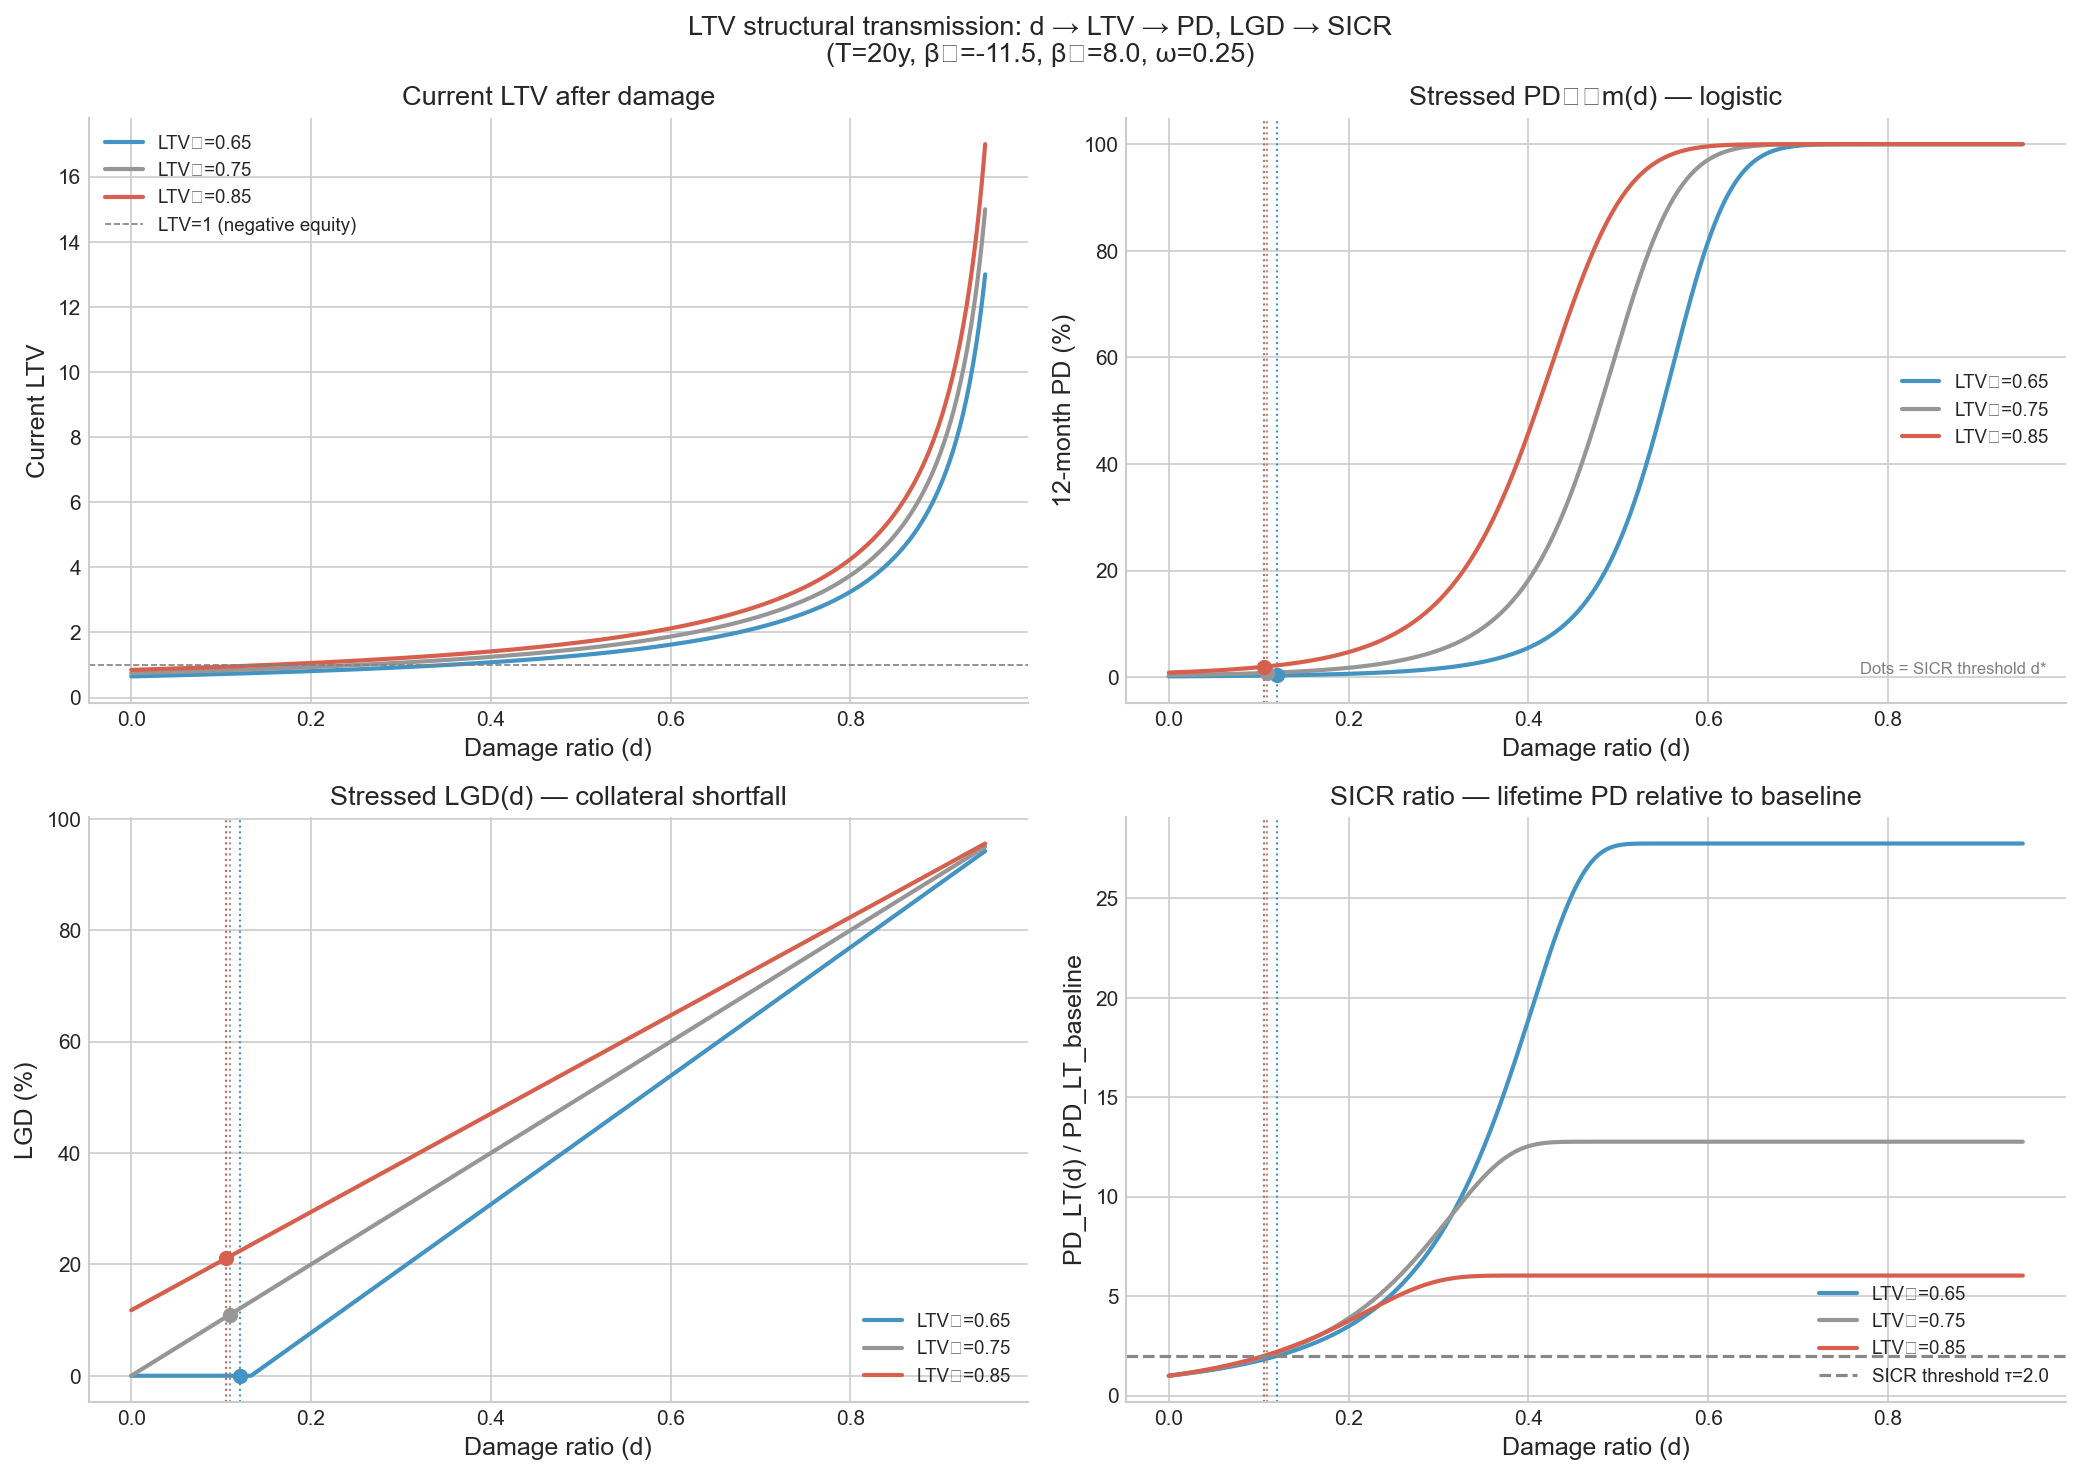

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ltv_0 in LTV_EXAMPLES:
    base   = baselines[ltv_0]
    d_star = base["d_star"]
    colour = COLOURS_LTV[ltv_0]
    label  = f"LTV₀={ltv_0:.2f}"

    metrics = compute_stressed_metrics(
        d_grid, np.full_like(d_grid, ltv_0),
        np.full_like(d_grid, T_EXAMPLE), BETA_0, BETA_1, OMEGA
    )

    # Panel 1: Current LTV(d)
    ax = axes[0, 0]
    ax.plot(d_grid, metrics["ltv_d"], color=colour, lw=2, label=label)

    # Panel 2: PD₁₂m(d)
    ax = axes[0, 1]
    ax.plot(d_grid, metrics["pd_12m"] * 100, color=colour, lw=2, label=label)
    if not np.isnan(d_star):
        pd_at_dstar = logistic_pd(
            np.array([ltv_0 / (1 - d_star)]), BETA_0, BETA_1
        )[0]
        ax.axvline(d_star, color=colour, lw=1, ls=":")
        ax.scatter([d_star], [pd_at_dstar * 100], color=colour, s=40, zorder=5)

    # Panel 3: LGD(d)
    ax = axes[1, 0]
    ax.plot(d_grid, metrics["lgd"] * 100, color=colour, lw=2, label=label)
    if not np.isnan(d_star):
        lgd_at_dstar = collateral_shortfall_lgd(
            np.array([ltv_0]), np.array([d_star]), OMEGA
        )[0]
        ax.axvline(d_star, color=colour, lw=1, ls=":")
        ax.scatter([d_star], [lgd_at_dstar * 100], color=colour, s=40, zorder=5)

    # Panel 4: SICR ratio PD_LT(d) / PD_LT_baseline
    ax = axes[1, 1]
    sicr_ratio = metrics["pd_lt"] / base["pd_lt"]
    ax.plot(d_grid, sicr_ratio, color=colour, lw=2, label=label)
    if not np.isnan(d_star):
        ax.axvline(d_star, color=colour, lw=1, ls=":")

# Formatting
ax = axes[0, 0]
ax.axhline(1.0, color="grey", lw=0.8, ls="--", label="LTV=1 (negative equity)")
ax.set_xlabel("Damage ratio (d)")
ax.set_ylabel("Current LTV")
ax.set_title("Current LTV after damage")
ax.legend(fontsize=9)

ax = axes[0, 1]
ax.set_xlabel("Damage ratio (d)")
ax.set_ylabel("12-month PD (%)")
ax.set_title("Stressed PD₁₂m(d) — logistic")
ax.legend(fontsize=9)
ax.text(0.98, 0.05, "Dots = SICR threshold d*", transform=ax.transAxes,
        ha="right", fontsize=8, color="grey")

ax = axes[1, 0]
ax.set_xlabel("Damage ratio (d)")
ax.set_ylabel("LGD (%)")
ax.set_title("Stressed LGD(d) — collateral shortfall")
ax.legend(fontsize=9)

ax = axes[1, 1]
ax.axhline(TAU, color=COLOURS["threshold"], lw=1.5, ls="--",
           label=f"SICR threshold τ={TAU}")
ax.set_xlabel("Damage ratio (d)")
ax.set_ylabel("PD_LT(d) / PD_LT_baseline")
ax.set_title("SICR ratio — lifetime PD relative to baseline")
ax.legend(fontsize=9)

fig.suptitle(
    f"LTV structural transmission: d → LTV → PD, LGD → SICR\n"
    f"(T={T_EXAMPLE}y, β₀={BETA_0}, β₁={BETA_1}, ω={OMEGA})",
    fontsize=13
)
plt.tight_layout()
plt.savefig("../../outputs/figures/decision1/03_transmission_chain.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. The ECL discontinuity — the central mechanism

The key figure for the paper. ECL is continuous in d within each stage, but **jumps discontinuously at d\*** when the loan crosses from Stage 1 (12-month ECL) to Stage 2 (lifetime ECL).

A vendor reporting d just below d\* → Stage 1 provision.
A vendor reporting d just above d\* → Stage 2 provision — potentially 5–15× larger.

This discontinuity is what makes vendor model choice financially material.

C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_31972\907463845.py:69: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_31972\907463845.py:70: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig("../../outputs/figures/decision1/03_ecl_discontinuity.png", dpi=300, bbox_inches="tight")


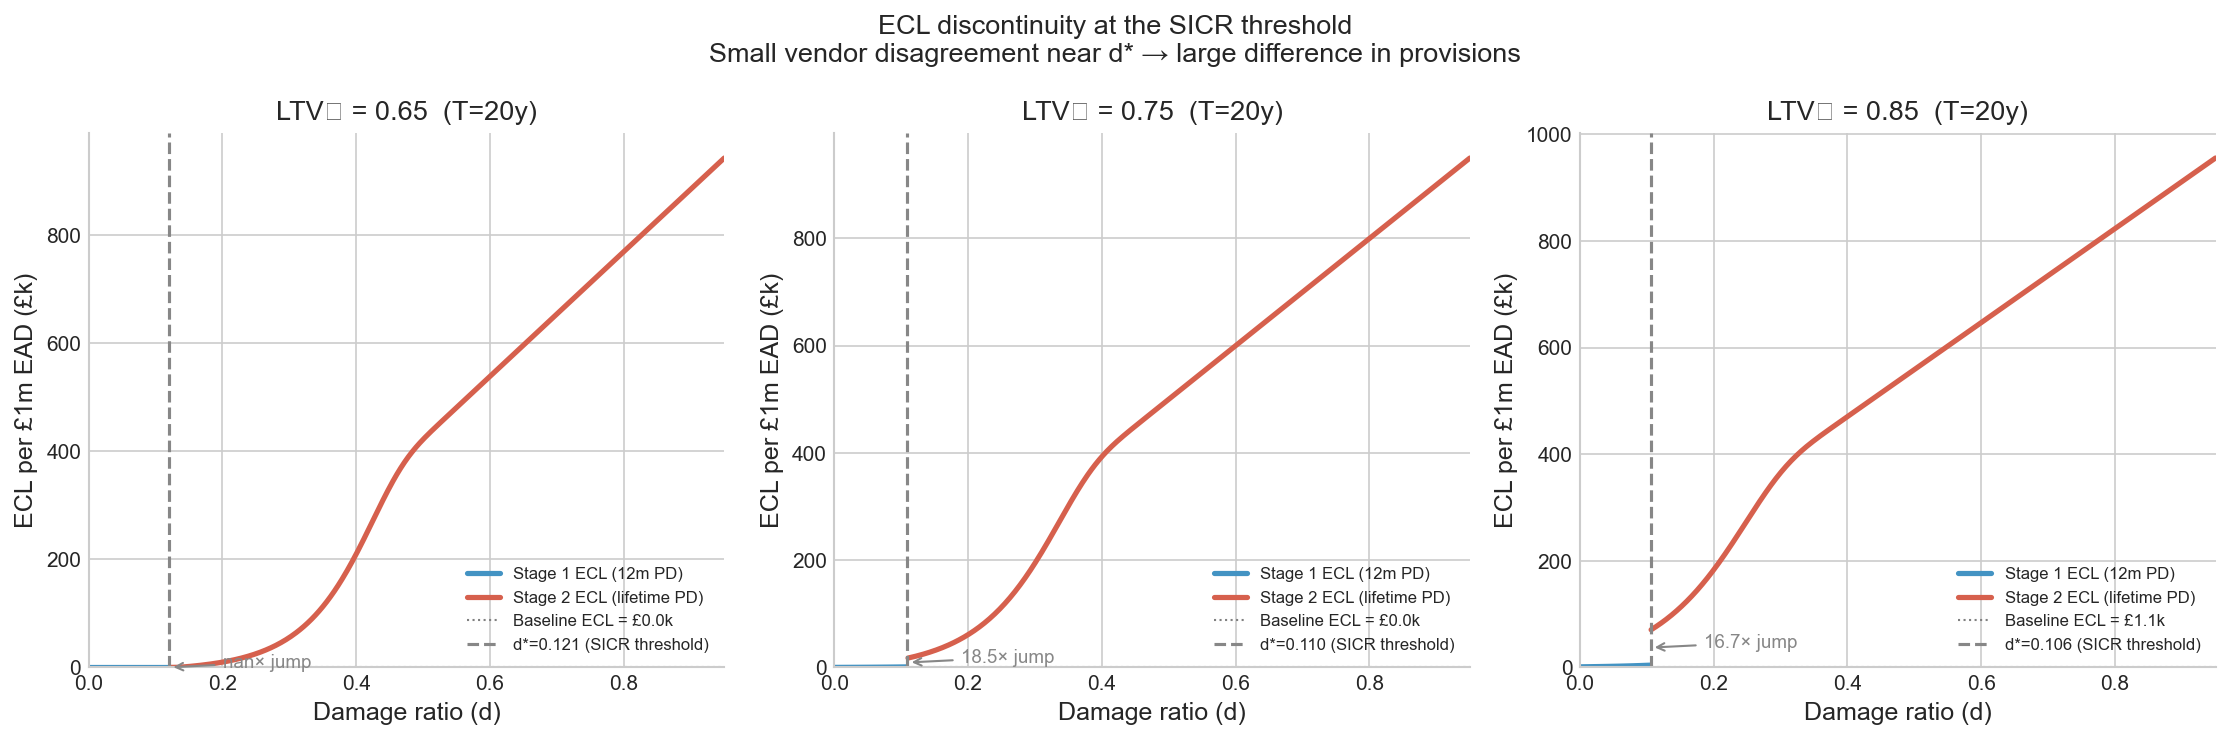

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, ltv_0 in zip(axes, LTV_EXAMPLES):
    base   = baselines[ltv_0]
    d_star = base["d_star"]
    colour = COLOURS_LTV[ltv_0]

    result = compute_ecl(
        d_grid,
        np.full_like(d_grid, ltv_0),
        np.full_like(d_grid, T_EXAMPLE),
        np.full_like(d_grid, EAD_EXAMPLE),
        np.full_like(d_grid, base["pd_lt"]),
        BETA_0, BETA_1, OMEGA, TAU,
    )

    ecl_k      = result["ecl_m"] * 1000
    in_stage2  = result["stage"] == 2

    # Stage 1 (solid) and Stage 2 (dashed) segments
    ax.plot(d_grid[~in_stage2], ecl_k[~in_stage2],
            color=COLOURS["stage1"], lw=2.5, label="Stage 1 ECL (12m PD)")
    ax.plot(d_grid[in_stage2],  ecl_k[in_stage2],
            color=COLOURS["stage2"], lw=2.5, label="Stage 2 ECL (lifetime PD)")

    # Baseline ECL (d=0)
    ecl_base_k = base["pd_12m"] * base["lgd"] * EAD_EXAMPLE * 1000
    ax.axhline(ecl_base_k, color="grey", lw=1, ls=":", label=f"Baseline ECL = £{ecl_base_k:.1f}k")

    # SICR threshold
    if not np.isnan(d_star):
        # ECL just below and just above d*
        ecl_just_below = compute_ecl(
            np.array([d_star - 1e-4]),
            np.array([ltv_0]), np.array([T_EXAMPLE]),
            np.array([EAD_EXAMPLE]), np.array([base["pd_lt"]]),
            BETA_0, BETA_1, OMEGA, TAU,
        )["ecl_m"][0] * 1000
        ecl_just_above = compute_ecl(
            np.array([d_star + 1e-4]),
            np.array([ltv_0]), np.array([T_EXAMPLE]),
            np.array([EAD_EXAMPLE]), np.array([base["pd_lt"]]),
            BETA_0, BETA_1, OMEGA, TAU,
        )["ecl_m"][0] * 1000
        jump = ecl_just_above / ecl_just_below if ecl_just_below > 0 else np.nan

        ax.axvline(d_star, color=COLOURS["threshold"], lw=1.5, ls="--",
                   label=f"d*={d_star:.3f} (SICR threshold)")
        ax.annotate(
            f"{jump:.1f}× jump",
            xy=(d_star, (ecl_just_below + ecl_just_above) / 2),
            xytext=(d_star + 0.08, (ecl_just_below + ecl_just_above) / 2),
            fontsize=9, color=COLOURS["threshold"],
            arrowprops=dict(arrowstyle="->", color=COLOURS["threshold"], lw=1),
        )

    ax.set_xlabel("Damage ratio (d)")
    ax.set_ylabel("ECL per £1m EAD (£k)")
    ax.set_title(f"LTV₀ = {ltv_0:.2f}  (T={T_EXAMPLE}y)")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 0.95)
    ax.set_ylim(bottom=0)

fig.suptitle(
    "ECL discontinuity at the SICR threshold\n"
    "Small vendor disagreement near d* → large difference in provisions",
    fontsize=13
)
plt.tight_layout()
plt.savefig("../../outputs/figures/decision1/03_ecl_discontinuity.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. How d\* varies with LTV₀ and maturity

The SICR threshold d\* is not fixed — it depends on the loan's LTV₀ and maturity T. High-LTV₀ loans are already closer to the logistic inflection point, so they need less damage to double their lifetime PD. Longer-maturity loans have higher baseline lifetime PDs, making the doubling threshold easier to hit.

C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_31972\3825600394.py:35: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_31972\3825600394.py:35: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_31972\3825600394.py:36: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig("../../outputs/figures/decision1/03_sicr_threshold_surface.png", dpi=300, bbox_inches="tight")
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_31972\3825600394.py:36: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig("../../outputs/figures/decision1/03_sicr_threshold_surface.png", dpi=300, bbox_inches="tight")


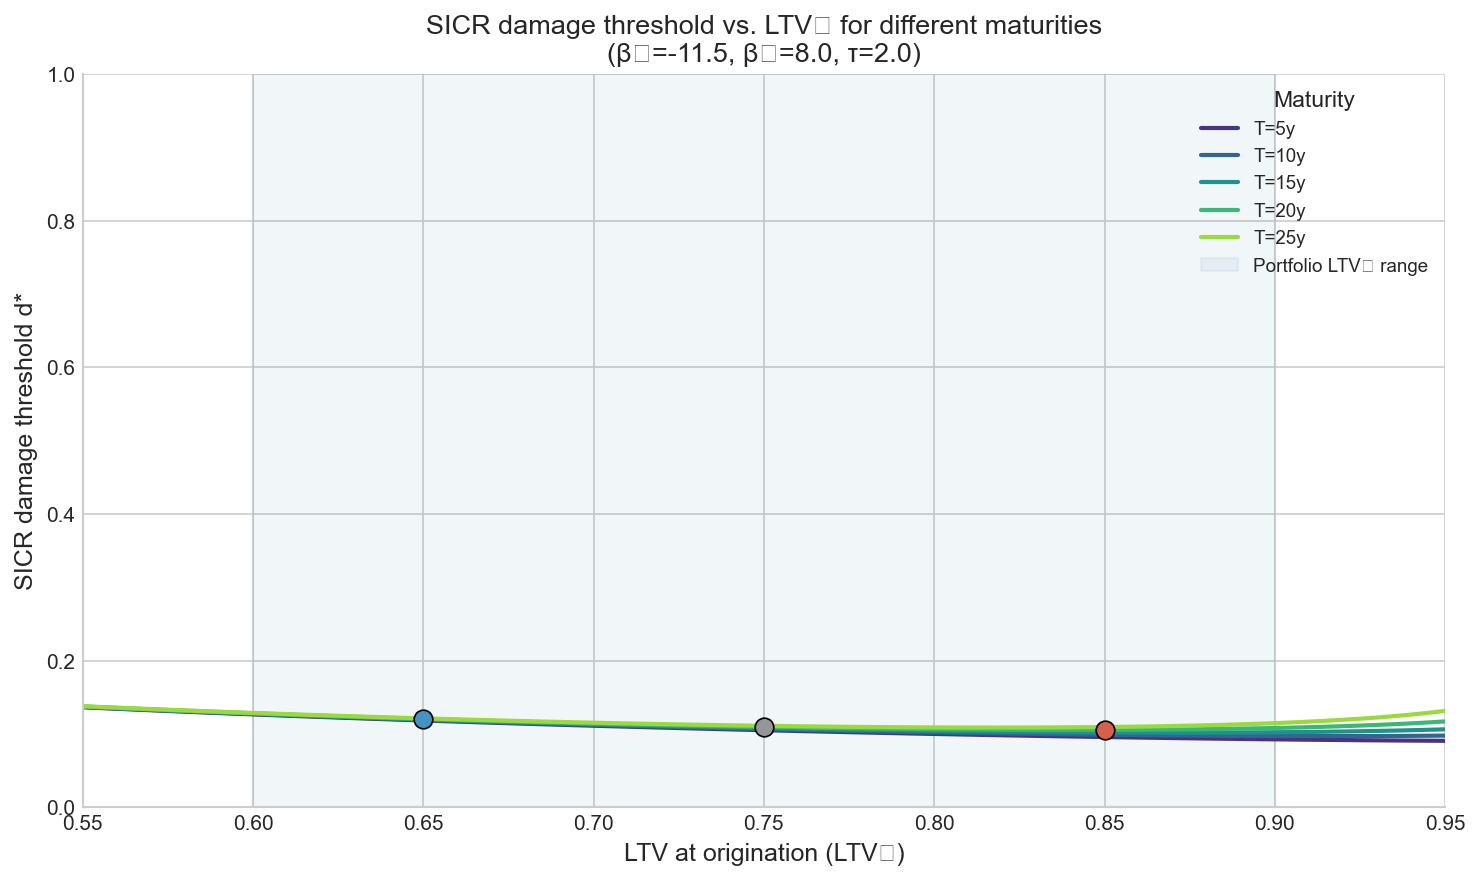

Key read: higher LTV₀ → lower d* → more sensitive to vendor disagreement
         longer maturity → lower d* → same direction


In [17]:
ltv_grid_fine = np.linspace(0.55, 0.95, 100)
maturities    = [5, 10, 15, 20, 25]
mat_colours   = plt.cm.viridis(np.linspace(0.15, 0.85, len(maturities)))

fig, ax = plt.subplots(figsize=(10, 6))

for T, col in zip(maturities, mat_colours):
    d_stars = np.array([
        sicr_damage_threshold(ltv, T, BETA_0, BETA_1, TAU)
        for ltv in ltv_grid_fine
    ])
    valid = ~np.isnan(d_stars)
    ax.plot(ltv_grid_fine[valid], d_stars[valid], color=col, lw=2, label=f"T={T}y")

# Shade the LTV₀ range of our portfolio
ax.axvspan(0.60, 0.90, alpha=0.07, color="steelblue", label="Portfolio LTV₀ range")

# Mark our three example loans
for ltv_0 in LTV_EXAMPLES:
    d_star = baselines[ltv_0]["d_star"]
    if not np.isnan(d_star):
        ax.scatter([ltv_0], [d_star], s=80, zorder=5,
                   color=COLOURS_LTV[ltv_0], edgecolors="k", lw=0.8)

ax.set_xlabel("LTV at origination (LTV₀)")
ax.set_ylabel("SICR damage threshold d*")
ax.set_title(
    f"SICR damage threshold vs. LTV₀ for different maturities\n"
    f"(β₀={BETA_0}, β₁={BETA_1}, τ={TAU})"
)
ax.legend(fontsize=9, title="Maturity")
ax.set_xlim(0.55, 0.95)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("../../outputs/figures/decision1/03_sicr_threshold_surface.png", dpi=300, bbox_inches="tight")
plt.show()

print("Key read: higher LTV₀ → lower d* → more sensitive to vendor disagreement")
print("         longer maturity → lower d* → same direction")

## 5. Portfolio-level SICR sensitivity

Map the actual portfolio loans onto the d\* surface. Loans whose vendor uncertainty band (d_min to d_max) straddles d\* are the ones where vendor choice determines staging — these are the 'at-risk' loans.

In [18]:
# Classify loans by staging outcome relative to mean and max vendor estimates
valid          = portfolio.d_sicr_threshold.notna()
triggered_mean = portfolio.d_mean >= portfolio.d_sicr_threshold
triggered_max  = portfolio.d_max  >= portfolio.d_sicr_threshold
straddles      = triggered_max & ~triggered_mean & valid
always_s1      = ~triggered_max & valid
always_s2      = triggered_mean & valid
unreachable    = ~valid

print("=== Portfolio SICR classification ===")
print(f"Unreachable (d* > 1, always Stage 1): {unreachable.sum():3d} loans")
print(f"Always Stage 1 (max vendor < d*):      {always_s1.sum():3d} loans")
print(f"Straddles d* (vendor band crosses):    {straddles.sum():3d} loans  ← key uncertainty")
print(f"Always Stage 2 (mean vendor ≥ d*):     {always_s2.sum():3d} loans")

=== Portfolio SICR classification ===
Unreachable (d* > 1, always Stage 1):   0 loans
Always Stage 1 (max vendor < d*):       34 loans
Straddles d* (vendor band crosses):     30 loans  ← key uncertainty
Always Stage 2 (mean vendor ≥ d*):      36 loans


C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_31972\3287802977.py:69: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_31972\3287802977.py:70: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig("../../outputs/figures/decision1/03_portfolio_staging_classification.png",


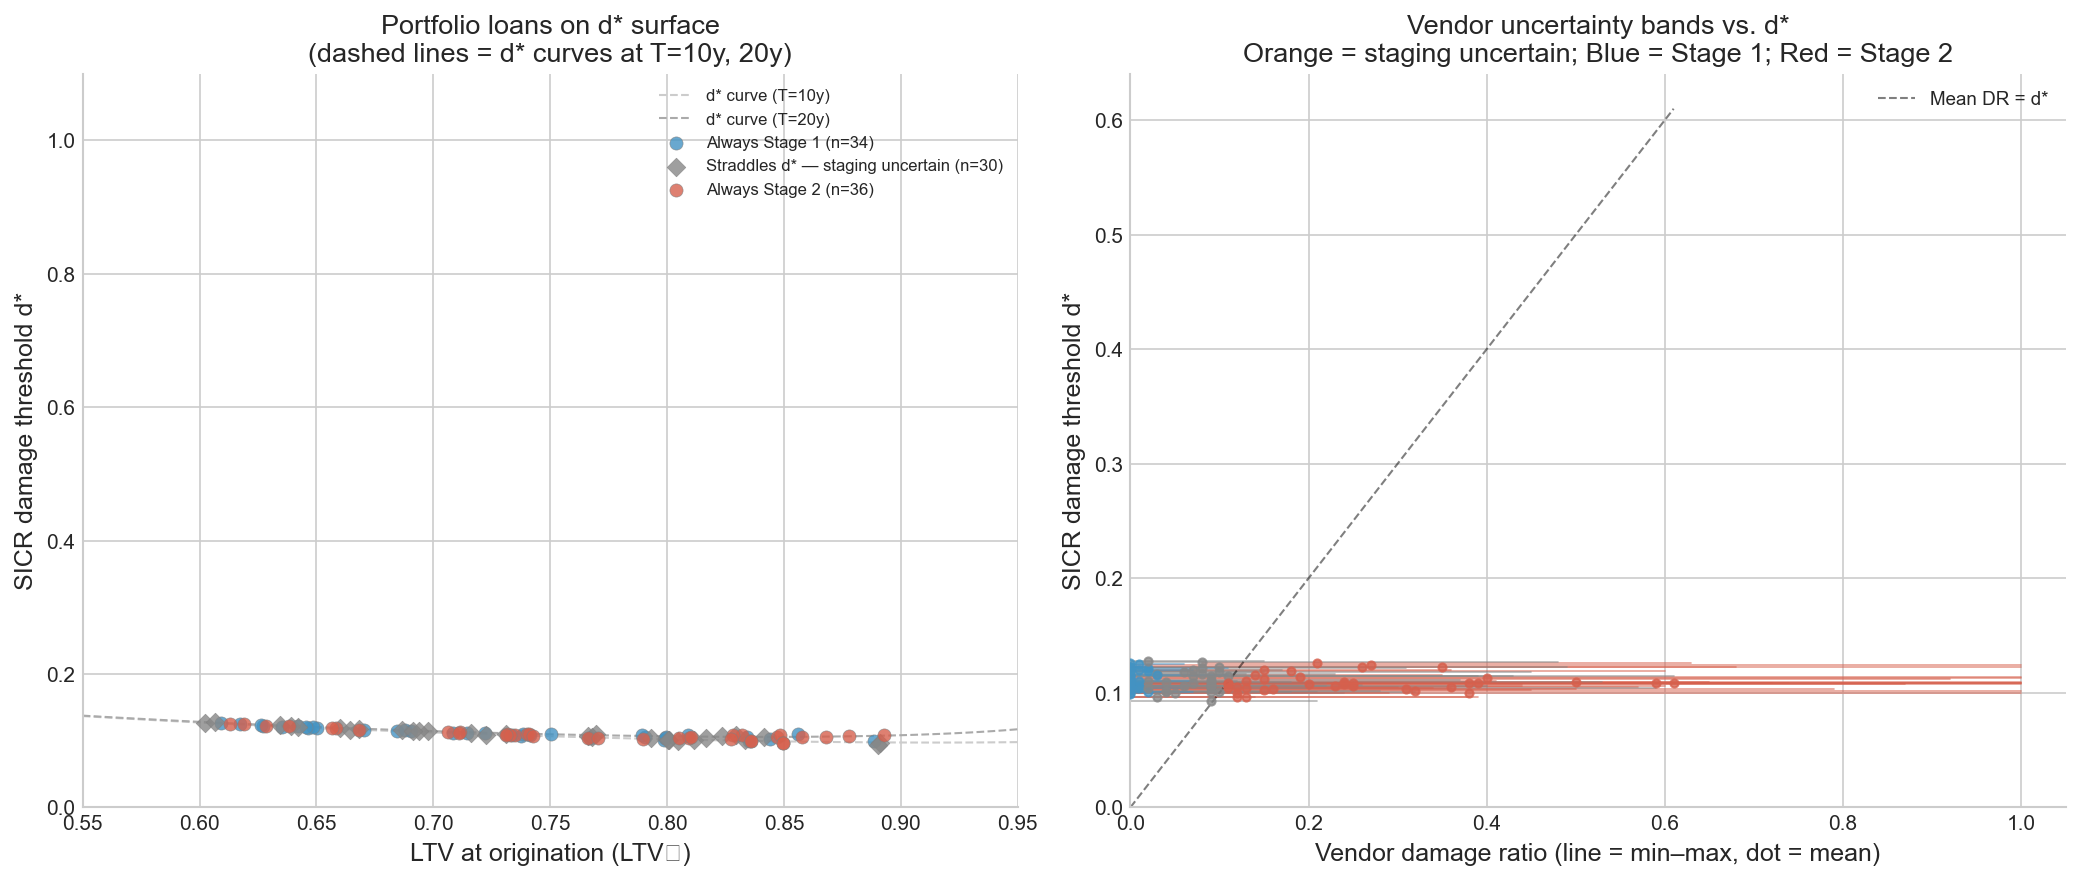

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: loan positions on d* vs LTV₀ plot, coloured by classification ---
ax = axes[0]

# Background d* curves for reference
for T, col in zip([10, 20], ["#cccccc", "#aaaaaa"]):
    d_stars = np.array([
        sicr_damage_threshold(ltv, T, BETA_0, BETA_1, TAU)
        for ltv in ltv_grid_fine
    ])
    valid_bg = ~np.isnan(d_stars)
    ax.plot(ltv_grid_fine[valid_bg], d_stars[valid_bg], color=col, lw=1,
            ls="--", label=f"d* curve (T={T}y)", zorder=1)

# Plot loans by classification
scatter_kwargs = dict(s=40, alpha=0.8, edgecolors="grey", linewidths=0.3, zorder=3)
ax.scatter(portfolio.loc[always_s1 | unreachable, "ltv_0"],
           portfolio.loc[always_s1 | unreachable, "d_sicr_threshold"].fillna(1.05),
           color=COLOURS["stage1"], label=f"Always Stage 1 (n={always_s1.sum() + unreachable.sum()})",
           **scatter_kwargs)
ax.scatter(portfolio.loc[straddles, "ltv_0"],
           portfolio.loc[straddles, "d_sicr_threshold"],
           color=COLOURS["threshold"], marker="D",
           label=f"Straddles d* — staging uncertain (n={straddles.sum()})",
           **scatter_kwargs)
ax.scatter(portfolio.loc[always_s2, "ltv_0"],
           portfolio.loc[always_s2, "d_sicr_threshold"],
           color=COLOURS["stage2"], label=f"Always Stage 2 (n={always_s2.sum()})",
           **scatter_kwargs)

ax.set_xlabel("LTV at origination (LTV₀)")
ax.set_ylabel("SICR damage threshold d*")
ax.set_title("Portfolio loans on d* surface\n(dashed lines = d* curves at T=10y, 20y)")
ax.legend(fontsize=8)
ax.set_xlim(0.55, 0.95)
ax.set_ylim(0, 1.1)

# --- Right: vendor band vs d* — the core uncertainty plot ---
ax = axes[1]
valid_p = portfolio[valid].copy()

# Error bars showing vendor range [d_min, d_max]
for _, row in valid_p.iterrows():
    if row.d_max < row.d_sicr_threshold:
        col = COLOURS["stage1"]
    elif row.d_mean >= row.d_sicr_threshold:
        col = COLOURS["stage2"]
    else:
        col = COLOURS["threshold"]
    ax.plot([row.d_min, row.d_max], [row.d_sicr_threshold, row.d_sicr_threshold],
            color=col, lw=0.8, alpha=0.6)
    ax.scatter([row.d_mean], [row.d_sicr_threshold], color=col, s=15, alpha=0.8, zorder=3)

# 45° line: mean DR = d*
lim = valid_p[["d_mean", "d_sicr_threshold"]].max().max()
ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.5, label="Mean DR = d*")

ax.set_xlabel("Vendor damage ratio (line = min–max, dot = mean)")
ax.set_ylabel("SICR damage threshold d*")
ax.set_title(
    f"Vendor uncertainty bands vs. d*\n"
    f"Orange = staging uncertain; Blue = Stage 1; Red = Stage 2"
)
ax.legend(fontsize=9)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("../../outputs/figures/decision1/03_portfolio_staging_classification.png",
            dpi=300, bbox_inches="tight")
plt.show()

## 6. LTV structural vs. reduced-form: side-by-side comparison

Verify that the qualitative result (ECL discontinuity at SICR threshold) holds under both transmission models. The reduced-form model uses independent PD₀ and LGD₀ matching the median portfolio loan.

In [20]:
# Representative loan for comparison — median portfolio characteristics
LTV_COMP   = 0.75
T_COMP     = 20
EAD_COMP   = 1.0

# LTV structural baseline
pd_12m_base_ltv = logistic_pd(np.array([LTV_COMP]), BETA_0, BETA_1)[0]
lgd_base_ltv    = collateral_shortfall_lgd(np.array([LTV_COMP]), np.array([0.0]), OMEGA)[0]
pd_lt_base_ltv  = lifetime_pd(np.array([pd_12m_base_ltv]), np.array([T_COMP]))[0]
d_star_ltv      = sicr_damage_threshold(LTV_COMP, T_COMP, BETA_0, BETA_1, TAU)

# Reduced-form: set PD₀ and LGD₀ to match the LTV structural baseline
# (so both models start from the same point at d=0)
PD0_RF  = pd_12m_base_ltv
LGD0_RF = lgd_base_ltv if lgd_base_ltv > 0 else 0.25   # fallback if LGD=0
pd_lt_base_rf = lifetime_pd(np.array([PD0_RF]), np.array([T_COMP]))[0]

# Solve d* for reduced-form
from scipy.optimize import brentq
target_rf = pd_lt_base_rf * TAU
def _rf_obj(d):
    pd_adj = min(PD0_RF * np.exp(ALPHA * d), 1.0)
    return (1 - (1 - pd_adj)**T_COMP) - target_rf
try:
    d_star_rf = brentq(_rf_obj, 0, 0.999) if _rf_obj(0.999) > 0 else np.nan
except ValueError:
    d_star_rf = np.nan

print(f"LTV structural model: PD₀={pd_12m_base_ltv*100:.3f}%, LGD₀={lgd_base_ltv*100:.1f}%, d*={d_star_ltv:.3f}")
print(f"Reduced-form model:   PD₀={PD0_RF*100:.3f}%, LGD₀={LGD0_RF*100:.1f}%, d*={d_star_rf:.3f}")

LTV structural model: PD₀=0.407%, LGD₀=0.0%, d*=0.110
Reduced-form model:   PD₀=0.407%, LGD₀=25.0%, d*=0.367


C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_31972\2896342960.py:54: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_31972\2896342960.py:55: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig("../../outputs/figures/decision1/03_model_comparison.png", dpi=300, bbox_inches="tight")


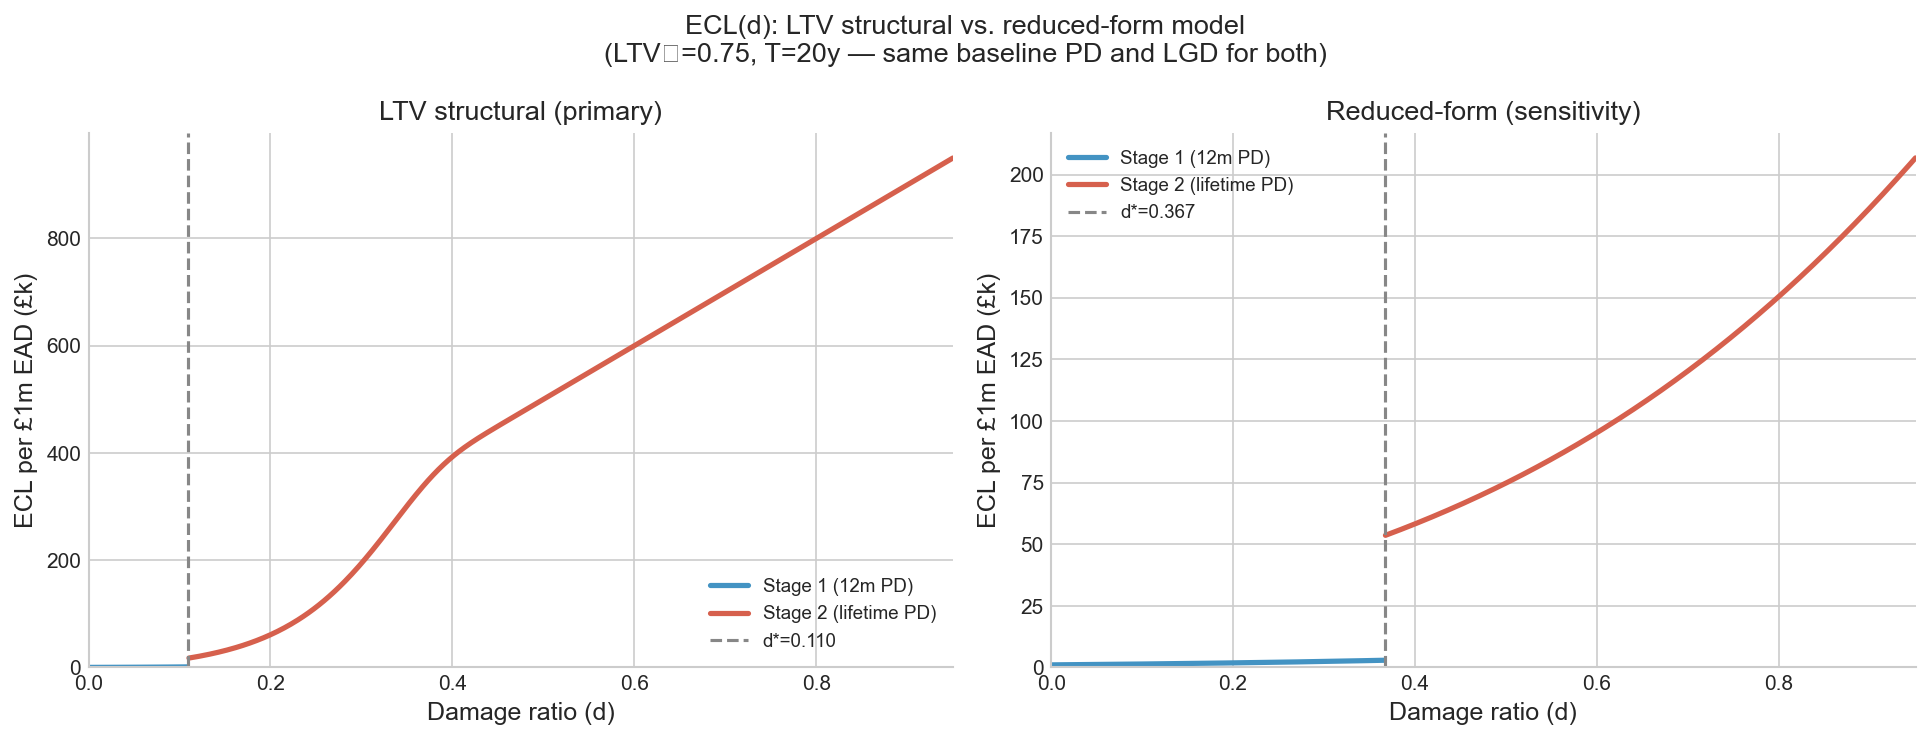

Both models produce the same qualitative result: a discontinuous ECL jump at the SICR threshold.
The structural model additionally captures the nonlinearity in PD from the 1/(1-d) LTV transformation.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model_name in zip(axes, ["LTV structural (primary)", "Reduced-form (sensitivity)"]):
    is_ltv = model_name.startswith("LTV")

    if is_ltv:
        result = compute_ecl(
            d_grid,
            np.full_like(d_grid, LTV_COMP),
            np.full_like(d_grid, T_COMP),
            np.full_like(d_grid, EAD_COMP),
            np.full_like(d_grid, pd_lt_base_ltv),
            BETA_0, BETA_1, OMEGA, TAU,
        )
        d_star = d_star_ltv
    else:
        pd_rf  = reduced_form_pd(PD0_RF, d_grid, ALPHA)
        lgd_rf = reduced_form_lgd(LGD0_RF, d_grid, LAMBDA)
        pd_lt_rf = lifetime_pd(pd_rf, np.full_like(d_grid, T_COMP))
        sicr_ratio_rf = pd_lt_rf / pd_lt_base_rf
        in_s2_rf = sicr_ratio_rf > TAU
        ecl_s1 = pd_rf  * lgd_rf * EAD_COMP
        ecl_s2 = pd_lt_rf * lgd_rf * EAD_COMP
        result = {
            "ecl_m": np.where(in_s2_rf, ecl_s2, ecl_s1),
            "stage": np.where(in_s2_rf, 2, 1).astype(int),
        }
        d_star = d_star_rf

    ecl_k     = result["ecl_m"] * 1000
    in_stage2 = result["stage"] == 2

    ax.plot(d_grid[~in_stage2], ecl_k[~in_stage2],
            color=COLOURS["stage1"], lw=2.5, label="Stage 1 (12m PD)")
    ax.plot(d_grid[in_stage2],  ecl_k[in_stage2],
            color=COLOURS["stage2"], lw=2.5, label="Stage 2 (lifetime PD)")

    if not np.isnan(d_star):
        ax.axvline(d_star, color=COLOURS["threshold"], lw=1.5, ls="--",
                   label=f"d*={d_star:.3f}")

    ax.set_xlabel("Damage ratio (d)")
    ax.set_ylabel("ECL per £1m EAD (£k)")
    ax.set_title(model_name)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 0.95)
    ax.set_ylim(bottom=0)

fig.suptitle(
    f"ECL(d): LTV structural vs. reduced-form model\n"
    f"(LTV₀={LTV_COMP}, T={T_COMP}y — same baseline PD and LGD for both)",
    fontsize=13
)
plt.tight_layout()
plt.savefig("../../outputs/figures/decision1/03_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Both models produce the same qualitative result: a discontinuous ECL jump at the SICR threshold.")
print("The structural model additionally captures the nonlinearity in PD from the 1/(1-d) LTV transformation.")

## 7. Conditional vs Unconditional Framing

The CFRF/GARP data reports damage ratios for the **1-in-200 year return period** flood — an event with annual exceedance probability p = 0.005.

Two valid framings of the SICR test exist:

| Framing | Assumption | PD used in SICR ratio | Practical interpretation |
|---------|------------|----------------------|--------------------------|
| **Conditional** (p = 1.0) | Flood certain | PD_stressed directly | Isolates vendor disagreement; worst-case staging |
| **Unconditional** (p = 0.005) | Flood probabilistic | (1−p_LT)·PD_base + p_LT·PD_stressed | Expected ECL uplift bank would actually book |

The unconditional framing dramatically raises the effective SICR bar. For τ = 2 and a 20-year loan:

$$\text{effective\_tau} = \frac{\tau - (1 - p_{LT})}{p_{LT}} = \frac{2 - (1 - 0.095)}{0.095} \approx 11.5$$

The stressed PD must be ~11.5× baseline (not 2×) to trigger SICR under the unconditional framing.

In [22]:
# --- Classify all portfolio loans under both framings at their mean damage ratio ---

p_flood = config["decision1_credit_risk"]["flood_hazard"]["annual_probability"]
tau     = TAU

d_mean_vals = portfolio["d_mean"].values

# Conditional classification (p = 1.0)
ecl_cond = compute_ecl(
    d=d_mean_vals,
    ltv_0=portfolio["ltv_0"].values,
    T=portfolio["maturity_years"].values,
    ead=portfolio["ead_m"].values,
    pd_lt_base=portfolio["baseline_pd_lt"].values,
    beta_0=BETA_0, beta_1=BETA_1, omega=OMEGA, tau=TAU,
    p_flood=1.0,
)

# Unconditional classification (p = 0.005)
ecl_uncond = compute_ecl(
    d=d_mean_vals,
    ltv_0=portfolio["ltv_0"].values,
    T=portfolio["maturity_years"].values,
    ead=portfolio["ead_m"].values,
    pd_lt_base=portfolio["baseline_pd_lt"].values,
    beta_0=BETA_0, beta_1=BETA_1, omega=OMEGA, tau=TAU,
    p_flood=p_flood,
)

stage_cond   = ecl_cond["stage"]
stage_uncond = ecl_uncond["stage"]

n2_cond   = (stage_cond   == 2).sum()
n2_uncond = (stage_uncond == 2).sum()
n_total   = len(portfolio)

cond_only   = ((stage_cond == 2) & (stage_uncond == 1)).sum()
uncond_only = ((stage_cond == 1) & (stage_uncond == 2)).sum()

print("SICR Classification at mean damage ratio (d_mean)")
print("=" * 52)
print(f"  Conditional   (p = 1.000): Stage 2 = {n2_cond:3d} / {n_total}  ({100*n2_cond/n_total:.1f}%)")
print(f"  Unconditional (p = {p_flood:.3f}): Stage 2 = {n2_uncond:3d} / {n_total}  ({100*n2_uncond/n_total:.1f}%)")
print()
print(f"  Loans Stage 2 under conditional only:   {cond_only}")
print(f"  Loans Stage 2 under unconditional only: {uncond_only}")
print()

# ECL comparison
ecl_cond_total   = ecl_cond["ecl_m"].sum()
ecl_uncond_total = ecl_uncond["ecl_m"].sum()
ecl_base_total   = portfolio["baseline_ecl_m"].sum()

print("Portfolio ECL at mean damage ratio")
print("=" * 52)
print(f"  Baseline ECL (d=0):                   £{ecl_base_total:.4f}m")
print(f"  Conditional   ECL (p = 1.0):          £{ecl_cond_total:.4f}m  ({ecl_cond_total/ecl_base_total:.1f}× baseline)")
print(f"  Unconditional ECL (p = {p_flood:.3f}):      £{ecl_uncond_total:.4f}m  ({ecl_uncond_total/ecl_base_total:.1f}× baseline)")

# Effective tau for each loan (varies by maturity)
p_lt_vals    = 1.0 - (1.0 - p_flood) ** portfolio["maturity_years"].values
eff_tau_vals = (TAU - (1.0 - p_lt_vals)) / p_lt_vals

print(f"\nEffective SICR threshold under unconditional framing")
print(f"  (tau = {TAU}, p = {p_flood})")
print(f"  Maturity range: {portfolio['maturity_years'].min()}–{portfolio['maturity_years'].max()} years")
print(f"  Effective tau range: {eff_tau_vals.min():.1f}× – {eff_tau_vals.max():.1f}×  (median {np.median(eff_tau_vals):.1f}×)")

SICR Classification at mean damage ratio (d_mean)
  Conditional   (p = 1.000): Stage 2 =  36 / 100  (36.0%)
  Unconditional (p = 0.005): Stage 2 =   3 / 100  (3.0%)

  Loans Stage 2 under conditional only:   33
  Loans Stage 2 under unconditional only: 0

Portfolio ECL at mean damage ratio
  Baseline ECL (d=0):                   £0.0265m
  Conditional   ECL (p = 1.0):          £3.9754m  (149.8× baseline)
  Unconditional ECL (p = 0.005):      £0.1550m  (5.8× baseline)

Effective SICR threshold under unconditional framing
  (tau = 2.0, p = 0.005)
  Maturity range: 5–25 years
  Effective tau range: 9.5× – 41.4×  (median 15.3×)


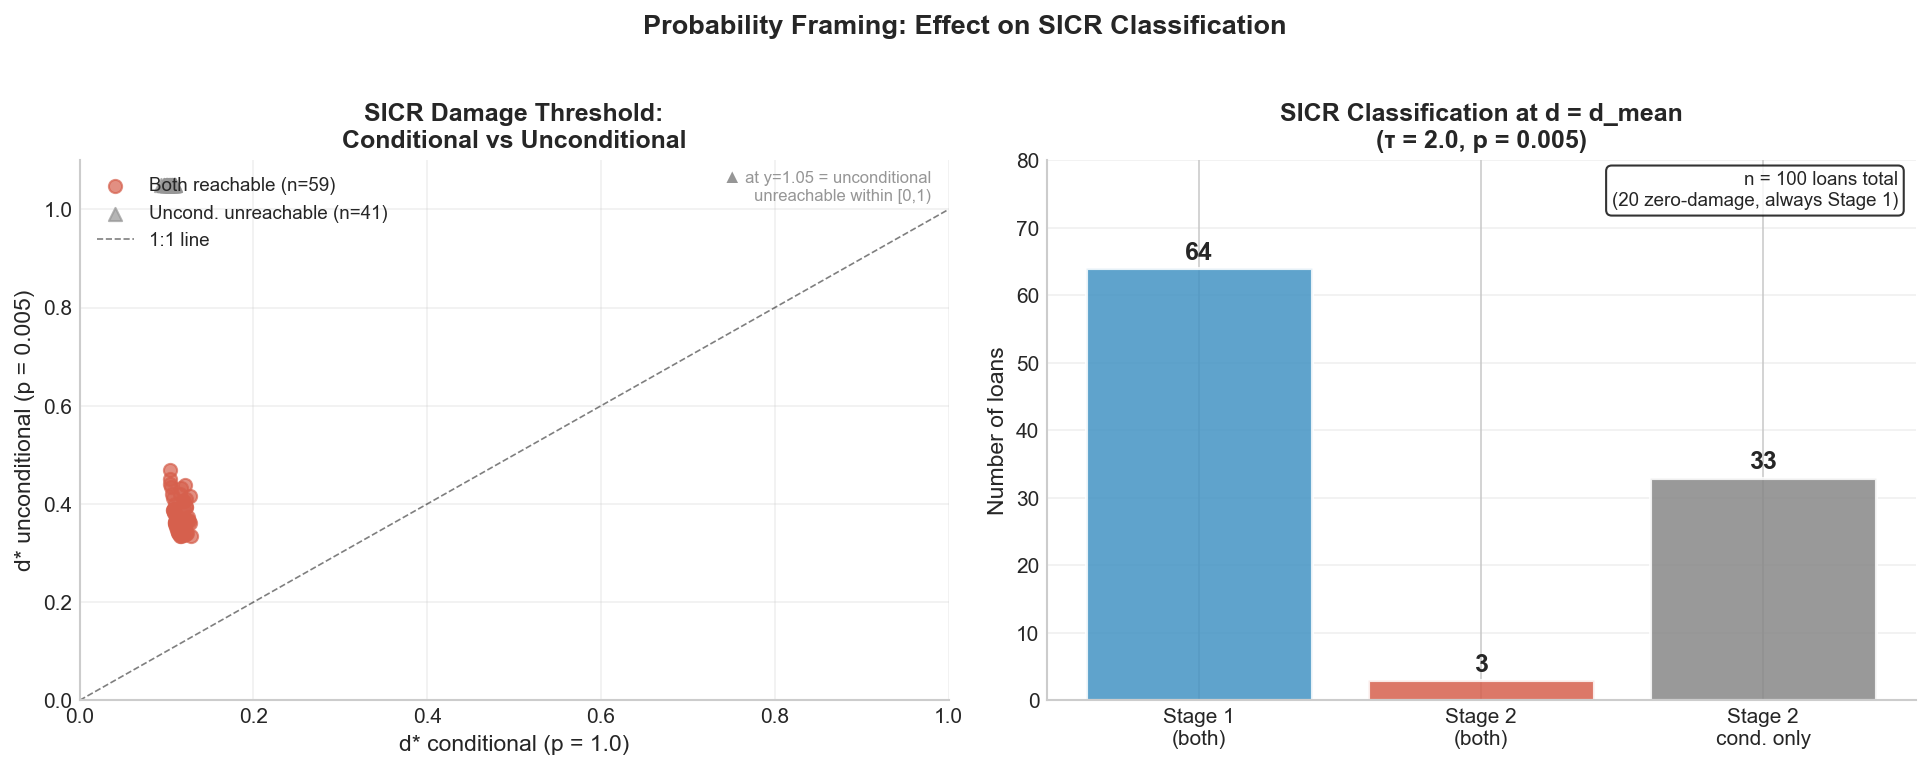

In [23]:
# --- Figure: d* scatter (conditional vs unconditional) + classification shift bar chart ---

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: d* scatter ─────────────────────────────────────────────────────────
ax = axes[0]

d_cond_vals   = portfolio["d_sicr_threshold"].values
d_uncond_vals = portfolio["d_sicr_uncond"].values

both_reach  = np.isfinite(d_cond_vals) & np.isfinite(d_uncond_vals)
cond_reach  = np.isfinite(d_cond_vals) & ~np.isfinite(d_uncond_vals)

ax.scatter(d_cond_vals[both_reach], d_uncond_vals[both_reach],
           c=COLOURS["stage2"], alpha=0.7, s=40,
           label=f"Both reachable (n={both_reach.sum()})", zorder=3)
ax.scatter(d_cond_vals[cond_reach], np.full(cond_reach.sum(), 1.05),
           c=COLOURS["grey"], alpha=0.7, s=40, marker="^",
           label=f"Uncond. unreachable (n={cond_reach.sum()})", zorder=3)

ax.plot([0, 1.0], [0, 1.0], "k--", lw=0.8, alpha=0.5, label="1:1 line")
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 1.1)
ax.set_xlabel("d* conditional (p = 1.0)", fontsize=11)
ax.set_ylabel("d* unconditional (p = 0.005)", fontsize=11)
ax.set_title("SICR Damage Threshold:\nConditional vs Unconditional", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="upper left")
ax.text(0.98, 0.98, "▲ at y=1.05 = unconditional\nunreachable within [0,1)",
        transform=ax.transAxes, ha="right", va="top", fontsize=8, color=COLOURS["grey"])
ax.grid(True, alpha=0.3)

# ── Right: classification bar chart ──────────────────────────────────────────
ax = axes[1]

both_s1      = ((stage_cond == 1) & (stage_uncond == 1)).sum()
both_s2      = ((stage_cond == 2) & (stage_uncond == 2)).sum()
cond_s2_only = ((stage_cond == 2) & (stage_uncond == 1)).sum()

n_zero = portfolio["is_zero_damage"].values.astype(bool).sum()

categories  = ["Stage 1\n(both)", "Stage 2\n(both)", "Stage 2\ncond. only"]
values      = [both_s1, both_s2, cond_s2_only]
colours_bar = [COLOURS["stage1"], COLOURS["stage2"], COLOURS["threshold"]]

bars = ax.bar(categories, values, color=colours_bar, edgecolor="white", linewidth=1.5, alpha=0.85)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(val), ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylabel("Number of loans", fontsize=11)
ax.set_title(f"SICR Classification at d = d_mean\n(τ = {TAU}, p = {p_flood})", fontsize=12, fontweight="bold")
ax.set_ylim(0, max(values) * 1.25)
ax.grid(True, axis="y", alpha=0.3)
ax.text(0.98, 0.98, f"n = {n_total} loans total\n({n_zero} zero-damage, always Stage 1)",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.suptitle("Probability Framing: Effect on SICR Classification", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../../outputs/figures/decision1/03_conditional_vs_unconditional_classification.png",
            dpi=300, bbox_inches="tight")
plt.show()

C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_31972\2752443382.py:60: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_31972\2752443382.py:61: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig("../../outputs/figures/decision1/03_ecl_curve_conditional_vs_unconditional.png",


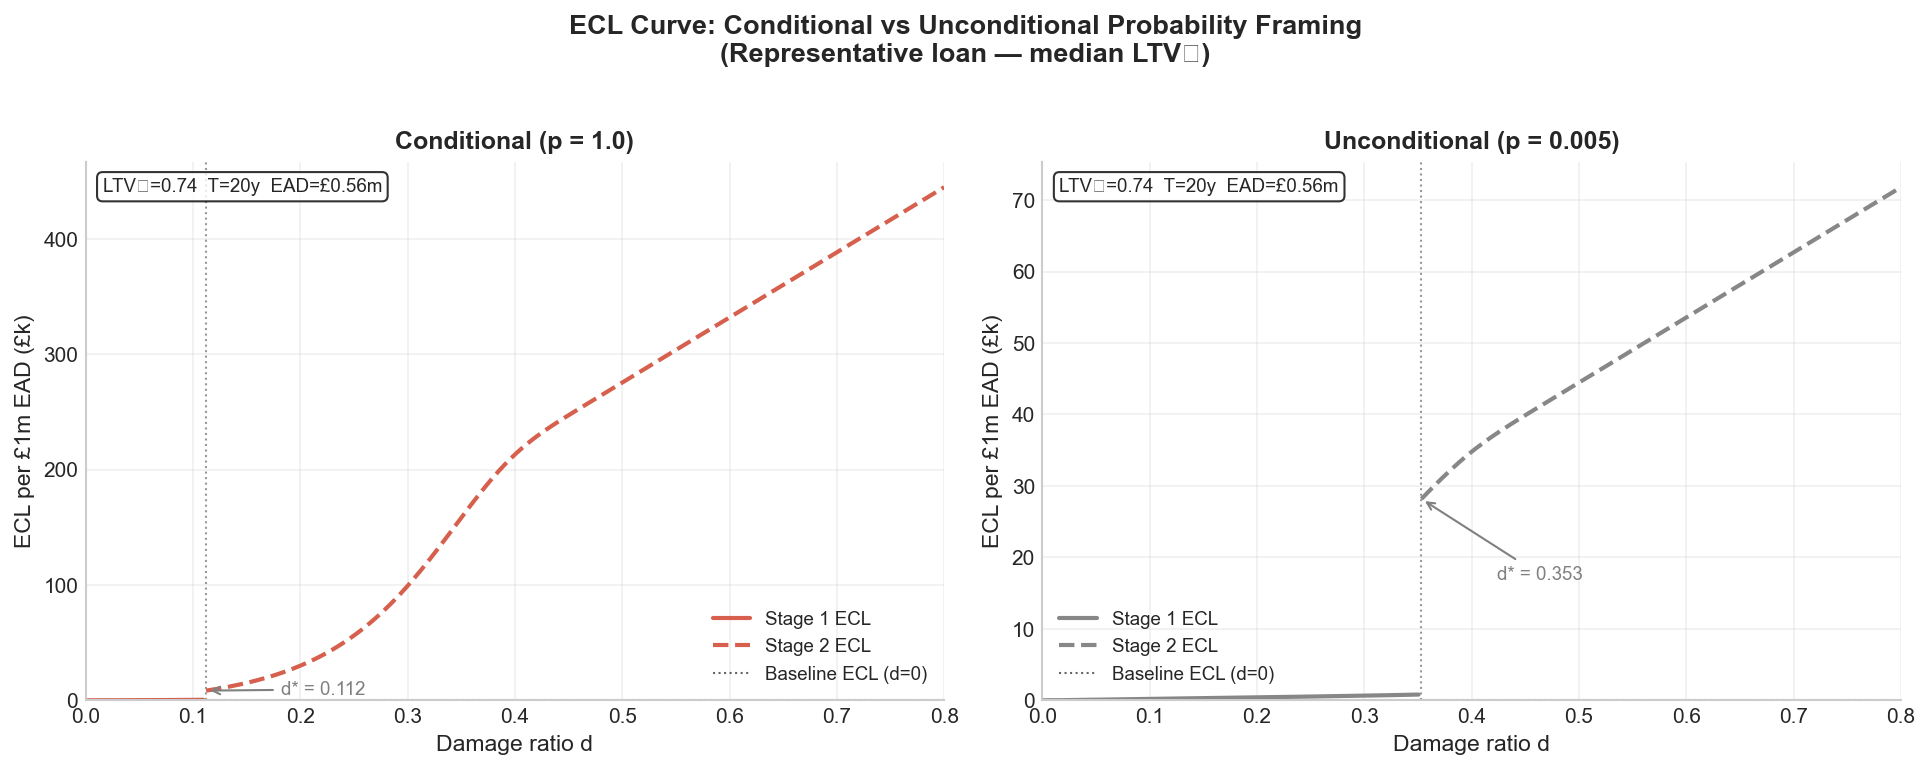


Representative loan: LTV₀=0.74, T=20y, EAD=£0.56m
  Conditional d*:   0.1104
  Unconditional d*: 0.3523


In [24]:
# --- Figure: ECL curve comparison — conditional vs unconditional ---
# Representative loan: median LTV₀

i_rep          = np.argsort(portfolio["ltv_0"].values)[len(portfolio) // 2]
ltv_rep        = portfolio["ltv_0"].values[i_rep]
T_rep          = int(portfolio["maturity_years"].values[i_rep])
ead_rep        = portfolio["ead_m"].values[i_rep]
pd_lt_base_rep = portfolio["baseline_pd_lt"].values[i_rep]

d_curve = np.linspace(0, 0.80, 300)

ecl_c = compute_ecl(
    d=d_curve, ltv_0=ltv_rep, T=T_rep, ead=ead_rep,
    pd_lt_base=pd_lt_base_rep,
    beta_0=BETA_0, beta_1=BETA_1, omega=OMEGA, tau=TAU, p_flood=1.0,
)
ecl_u = compute_ecl(
    d=d_curve, ltv_0=ltv_rep, T=T_rep, ead=ead_rep,
    pd_lt_base=pd_lt_base_rep,
    beta_0=BETA_0, beta_1=BETA_1, omega=OMEGA, tau=TAU, p_flood=p_flood,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, ecl_res, label, col in [
    (axes[0], ecl_c, f"Conditional (p = 1.0)",      COLOURS["stage2"]),
    (axes[1], ecl_u, f"Unconditional (p = {p_flood})", COLOURS["threshold"]),
]:
    s1 = ecl_res["stage"] == 1
    s2 = ecl_res["stage"] == 2

    ax.plot(d_curve[s1], ecl_res["ecl_m"][s1] * 1000, color=col, lw=2.0, label="Stage 1 ECL")
    ax.plot(d_curve[s2], ecl_res["ecl_m"][s2] * 1000, color=col, lw=2.0, ls="--", label="Stage 2 ECL")

    if s2.any():
        d_jump   = d_curve[s2][0]
        ecl_jump = ecl_res["ecl_m"][s2][0] * 1000
        ax.axvline(d_jump, color="grey", ls=":", lw=1.0, alpha=0.8)
        ax.annotate(f"d* = {d_jump:.3f}",
                    xy=(d_jump, ecl_jump),
                    xytext=(min(d_jump + 0.07, 0.72), ecl_jump * 0.6),
                    arrowprops=dict(arrowstyle="->", color="grey"), fontsize=9, color="grey")

    ax.axhline(portfolio["baseline_ecl_m"].values[i_rep] * 1000, color="black",
               ls=":", lw=1.0, alpha=0.6, label="Baseline ECL (d=0)")

    ax.set_xlabel("Damage ratio d", fontsize=11)
    ax.set_ylabel("ECL per £1m EAD (£k)", fontsize=11)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 0.80)
    ax.set_ylim(bottom=0)
    ax.text(0.02, 0.97, f"LTV₀={ltv_rep:.2f}  T={T_rep}y  EAD=£{ead_rep:.2f}m",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.suptitle("ECL Curve: Conditional vs Unconditional Probability Framing\n(Representative loan — median LTV₀)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../../outputs/figures/decision1/03_ecl_curve_conditional_vs_unconditional.png",
            dpi=300, bbox_inches="tight")
plt.show()

print(f"\nRepresentative loan: LTV₀={ltv_rep:.2f}, T={T_rep}y, EAD=£{ead_rep:.2f}m")
print(f"  Conditional d*:   {portfolio['d_sicr_threshold'].values[i_rep]:.4f}")
uncond_dstar = portfolio['d_sicr_uncond'].values[i_rep]
print(f"  Unconditional d*: {'NaN (unreachable)' if np.isnan(uncond_dstar) else f'{uncond_dstar:.4f}'}")

## 8. Summary

### LTV structural model — transmission chain

The notebook demonstrates the full damage-to-ECL transmission chain:

1. **Property damage** (d) destroys collateral value: PV(d) = PV₀ × (1 − d)
2. **LTV stress**: LTV(d) = LTV₀ / (1 − d) — rises nonlinearly with d
3. **PD stress**: logistic(β₀ + β₁ × LTV(d)) — accelerates as LTV passes 1.0
4. **LGD stress**: max(1 − (1−d)(1−ω)/LTV₀, 0) — grows linearly with d
5. **SICR test**: PD_LT(d) / PD_LT_baseline > τ → Stage 2
6. **ECL jump**: at d*, ECL switches from PD₁₂m×LGD×EAD to PD_LT×LGD×EAD

### Key structural properties

- **Coherence**: PD and LGD are both driven by the same state variable (current LTV), not independent assumptions
- **Nonlinearity**: PD as a function of d is highly nonlinear — modest damage above d≈0.3 can cause large PD spikes
- **Zero LGD threshold**: loans with LTV₀ < (1−ω) = 0.75 have zero baseline LGD; the collateral fully covers even after workout costs
- **d* distribution**: most reachable d* values cluster around 0.1–0.3 for the conditional framing

### Probability framing matters

The choice of conditional vs unconditional framing has major consequences:

| | Conditional (p = 1.0) | Unconditional (p = 0.005) |
|---|---|---|
| SICR threshold | τ = 2.0× | effective τ ≈ 6–15× (varies by maturity) |
| d* reachability | ~100% of loans | ~59% of loans |
| Median d* | ~0.11 | ~0.37 |
| Stage 2 at d_mean | More loans | Far fewer loans |
| ECL uplift | Higher (Stage 2 ECL) | Lower (probability-discounted) |

**Interpretation**: The conditional framing is appropriate for stress-testing or isolating vendor disagreement effects. The unconditional framing better reflects what a bank would actually provision under IFRS 9, where ECL must be probability-weighted.

### What Notebook 04 will do

Notebook 04 (simulation) will draw from the triangular vendor uncertainty distributions for each property and run a Monte Carlo simulation to determine how vendor disagreement translates into variation in:
- SICR classification (Stage 1 vs Stage 2) across vendor draws
- Portfolio-level ECL distribution
- Both correlation scenarios (independent vs perfectly correlated vendor draws)
- Both probability framings (conditional and unconditional)